# Analysis Notebook

Load saved numpy results and generate figures (no model loading).

In [1]:

import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "results").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
RESULTS_ROOT = PROJECT_ROOT / "results"
FIGURES_DIR = RESULTS_ROOT / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

ARCHS = {
    "resnet50": {
        "methods": [
            "gradient", "smoothgrad", "input_grad", "ig", "gradcam",
            "gbp", "gbp_gc",
        ],
        "title": "ResNet-50",
    },
    "vit": {
        "methods": [
            "gradient", "smoothgrad", "input_grad", "ig", "gradcam",
            "raw_attn", "rollout",
        ],
        "title": "ViT-B/16",
    },
    "dinov2": {
        "methods": [
            "gradient", "smoothgrad", "input_grad", "ig", "gradcam",
            "raw_attn", "rollout",
        ],
        "title": "DINOv2-B",
    },
}
SHARED_METHODS = [
    "gradient", "smoothgrad", "input_grad", "ig", "gradcam",
]
CROSS_ARCH_LABELS = {
    "resnet50": "ResNet-50",
    "vit": "ViT-B/16",
    "dinov2": "DINOv2-B",
}
MECH_ARCH_TAGS = [
    ("resnet", "ResNet-50"),
    ("vit", "ViT-B/16"),
    ("dinov2", "DINOv2-B"),
]
VIT_ATTENTION_METHODS = ["raw_attn", "rollout"]
CROSS_VIT_LABELS = {"vit": "ViT-B/16", "dinov2": "DINOv2-B"}


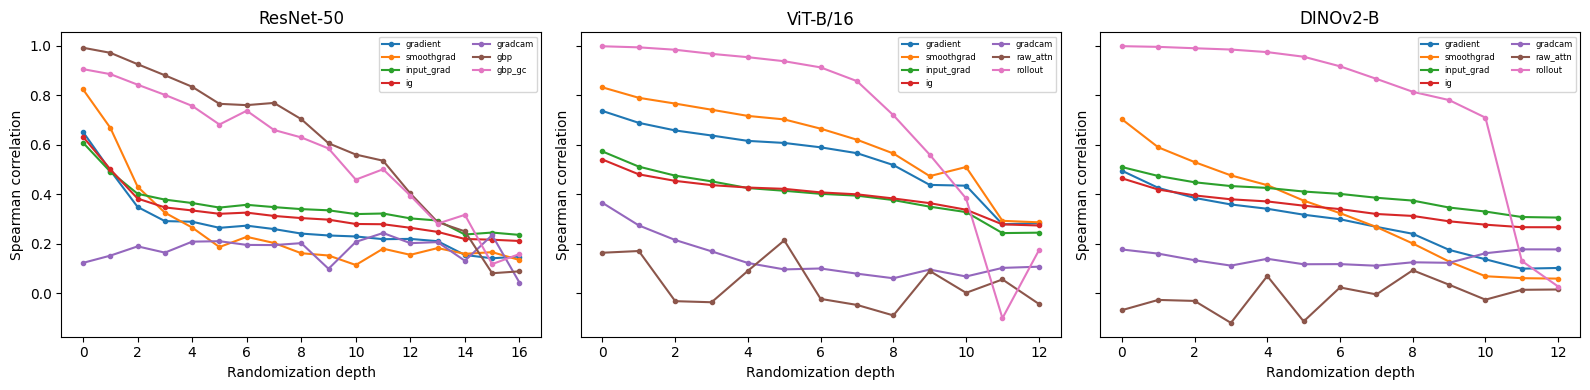

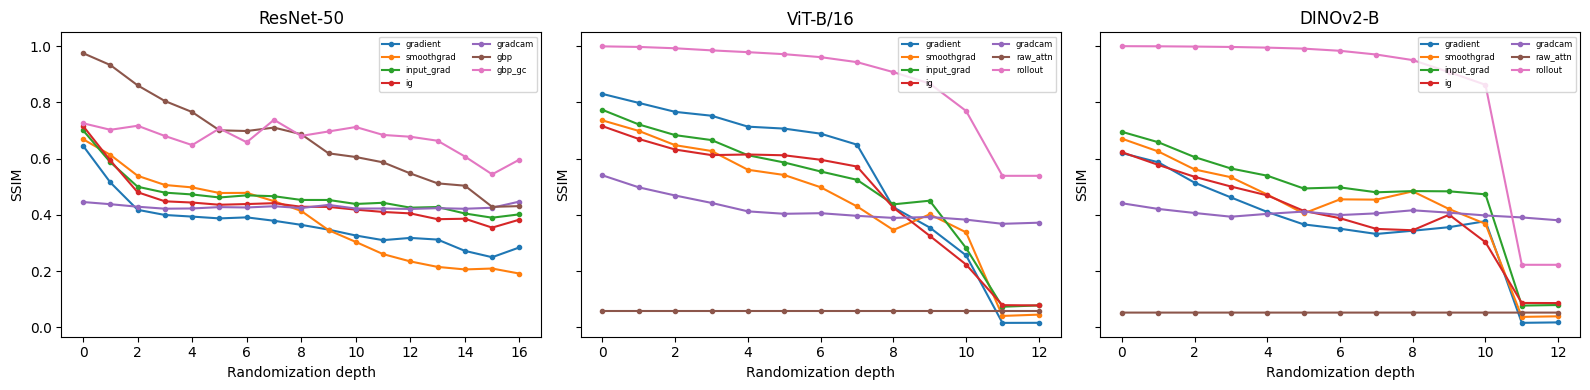

In [2]:

def plot_metric_curves(metric_suffix, ylabel, fname):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
    for ax, (arch, cfg) in zip(axes, ARCHS.items()):
        d = RESULTS_ROOT / arch
        if not d.exists():
            ax.set_title(cfg["title"] + " (missing)")
            continue
        for method in cfg["methods"]:
            path = d / ("%s_%s.npy" % (method, metric_suffix))
            if not path.exists():
                continue
            vals = np.load(path)
            ax.plot(range(len(vals)), vals, marker="o", label=method, markersize=3)
        ax.set_xlabel("Randomization depth")
        ax.set_ylabel(ylabel)
        ax.set_title(cfg["title"])
        ax.legend(fontsize=6, ncol=2)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / fname, dpi=150)
    plt.show()

plot_metric_curves("spearman_mean", "Spearman correlation", "spearman_curves.png")
plot_metric_curves("ssim_mean", "SSIM", "ssim_curves.png")


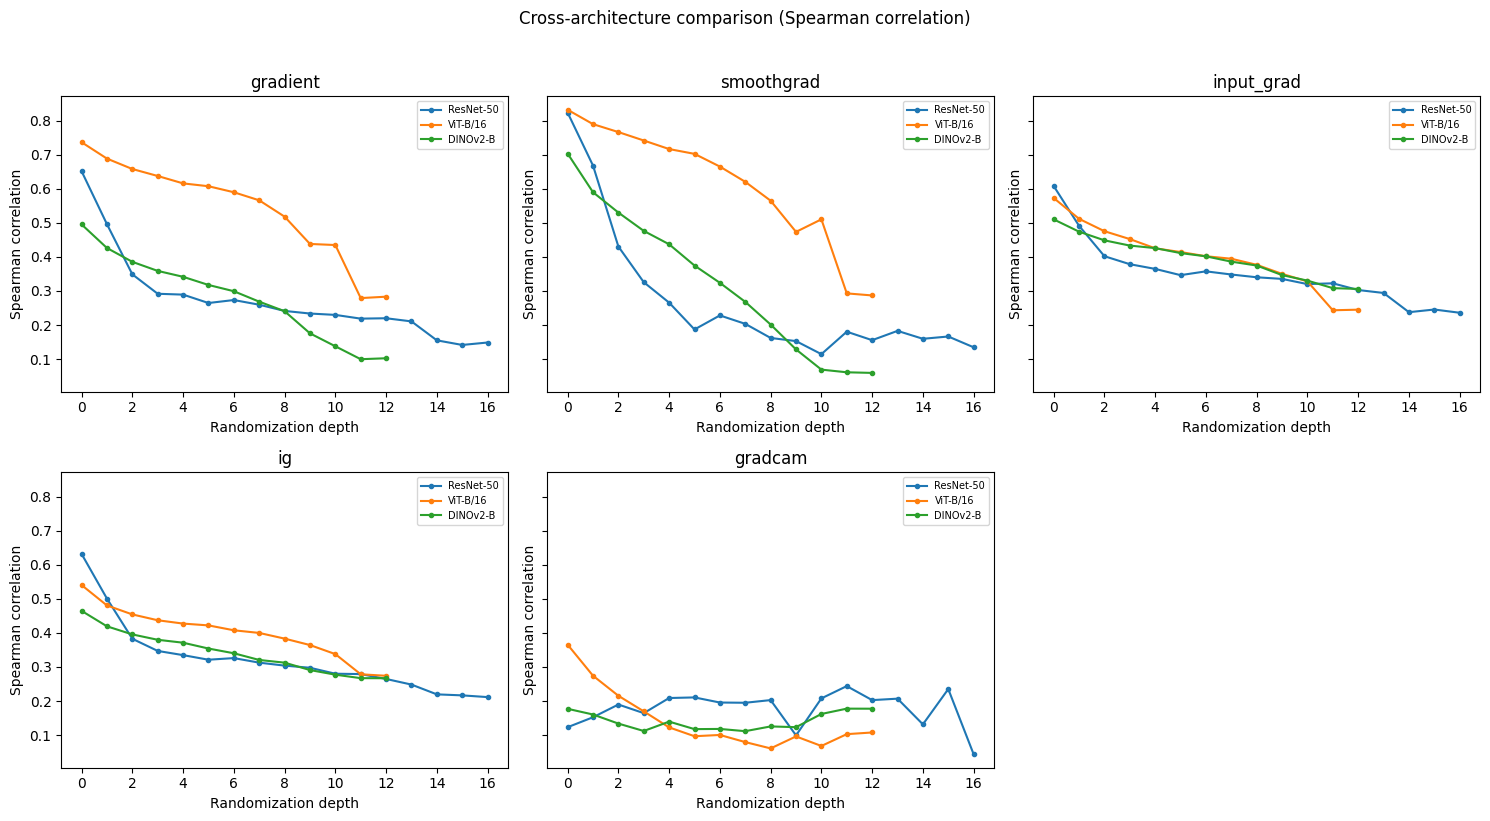

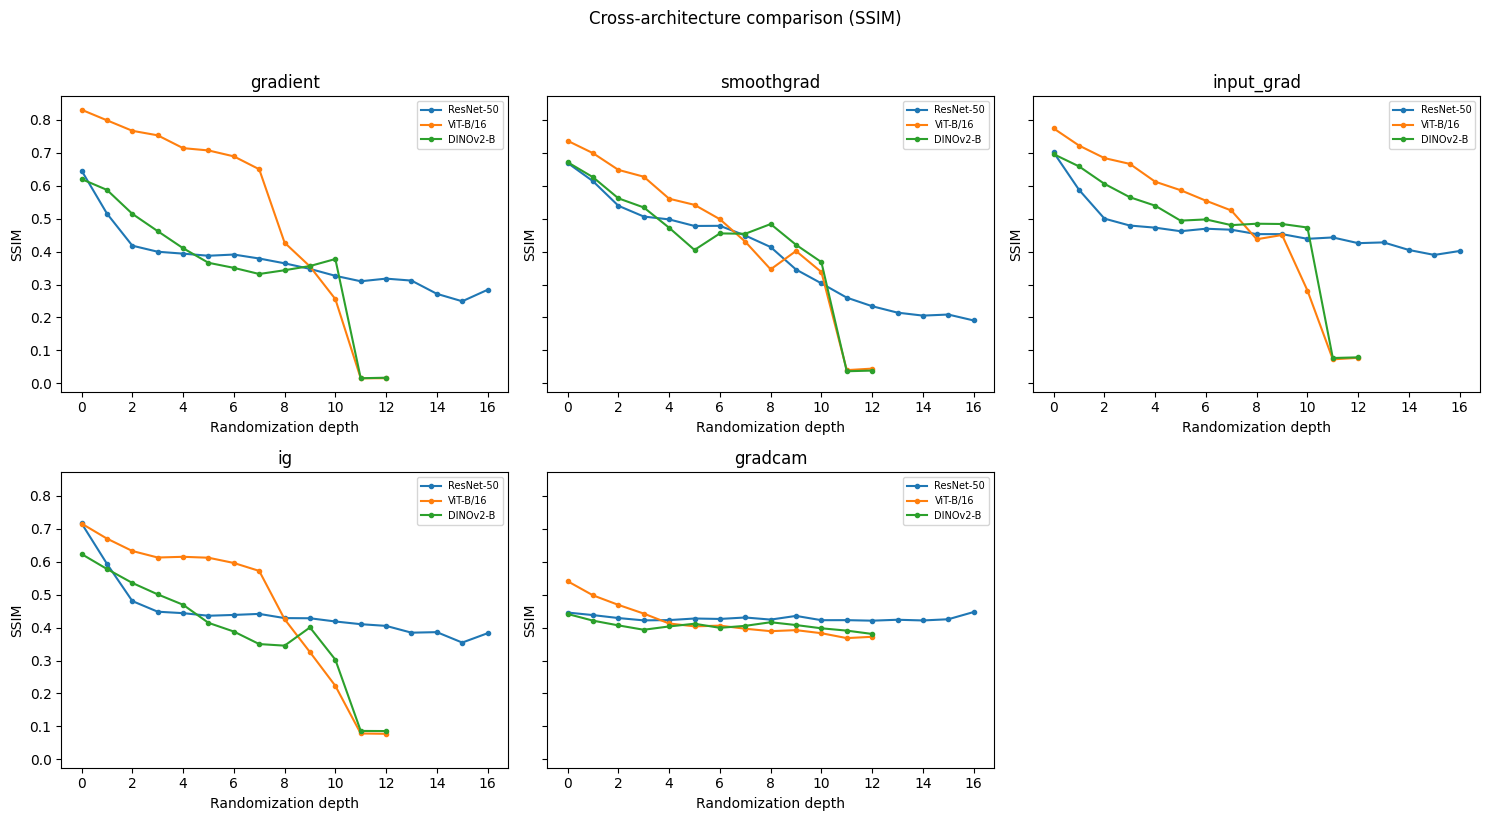

In [3]:

def plot_cross_arch_curves(metric_suffix, ylabel, fname):
    n_methods = len(SHARED_METHODS)
    ncols = 3
    nrows = int(np.ceil(n_methods / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), sharey=True)
    axes = np.atleast_1d(axes).flatten()
    for ax, method in zip(axes, SHARED_METHODS):
        for arch, label in CROSS_ARCH_LABELS.items():
            path = RESULTS_ROOT / arch / ("%s_%s.npy" % (method, metric_suffix))
            if not path.exists():
                continue
            vals = np.load(path)
            ax.plot(range(len(vals)), vals, marker="o", label=label, markersize=3)
        ax.set_xlabel("Randomization depth")
        ax.set_ylabel(ylabel)
        ax.set_title(method)
        ax.legend(fontsize=7)
    for ax in axes[n_methods:]:
        ax.axis("off")
    fig.suptitle("Cross-architecture comparison (%s)" % ylabel, y=1.02)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / fname, dpi=150, bbox_inches="tight")
    plt.show()

plot_cross_arch_curves("spearman_mean", "Spearman correlation", "cross_arch_spearman.png")
plot_cross_arch_curves("ssim_mean", "SSIM", "cross_arch_ssim.png")


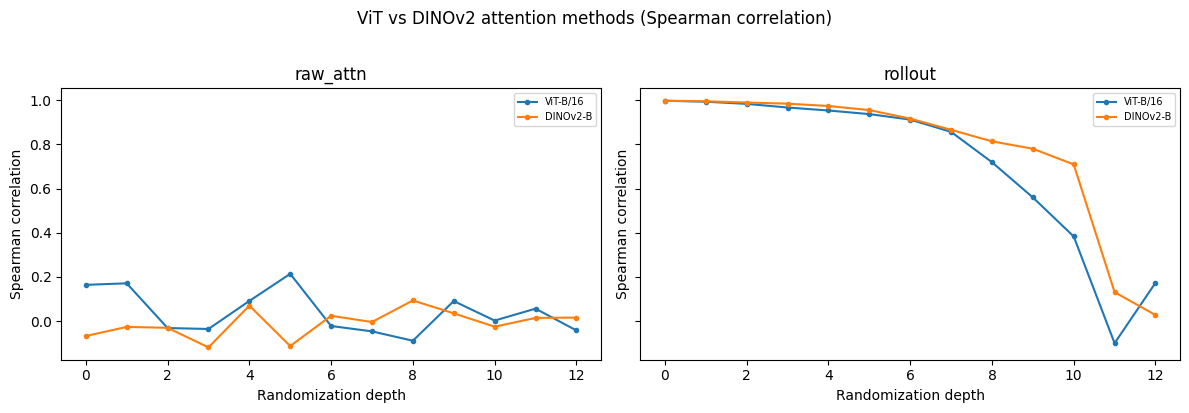

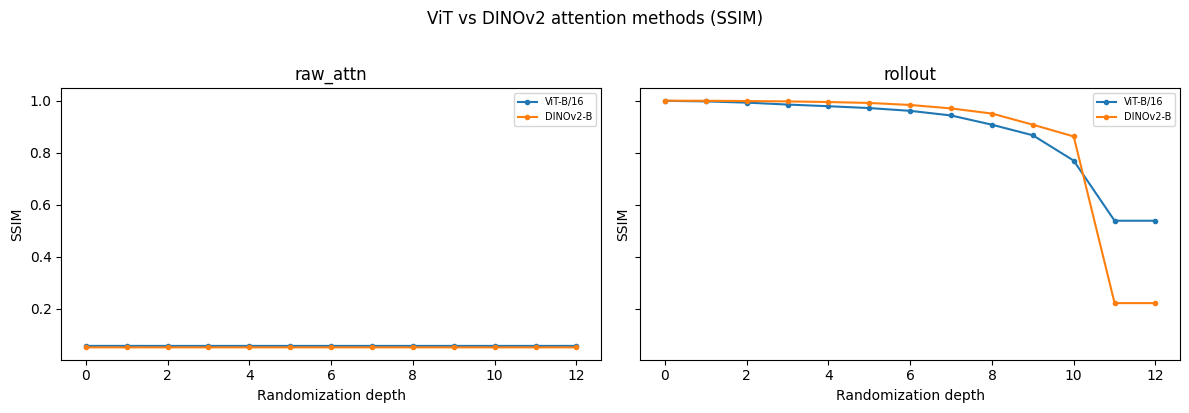

In [4]:

def plot_cross_vit_attention(metric_suffix, ylabel, fname):
    n_methods = len(VIT_ATTENTION_METHODS)
    fig, axes = plt.subplots(1, n_methods, figsize=(6 * n_methods, 4), sharey=True)
    if n_methods == 1:
        axes = [axes]
    for ax, method in zip(axes, VIT_ATTENTION_METHODS):
        for arch, label in CROSS_VIT_LABELS.items():
            path = RESULTS_ROOT / arch / ("%s_%s.npy" % (method, metric_suffix))
            if not path.exists():
                continue
            vals = np.load(path)
            ax.plot(range(len(vals)), vals, marker="o", label=label, markersize=3)
        ax.set_xlabel("Randomization depth")
        ax.set_ylabel(ylabel)
        ax.set_title(method)
        ax.legend(fontsize=7)
    fig.suptitle("ViT vs DINOv2 attention methods (%s)" % ylabel, y=1.02)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / fname, dpi=150, bbox_inches="tight")
    plt.show()

plot_cross_vit_attention("spearman_mean", "Spearman correlation", "cross_vit_attn_spearman.png")
plot_cross_vit_attention("ssim_mean", "SSIM", "cross_vit_attn_ssim.png")


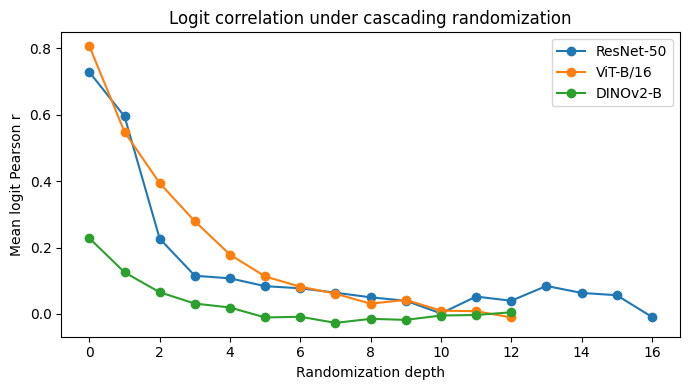

In [5]:

mech = RESULTS_ROOT / "mechanistic"
if any((mech / ("logit_corr_%s.npy" % tag)).exists() for tag, _ in MECH_ARCH_TAGS):
    fig, ax = plt.subplots(figsize=(7, 4))
    for tag, label in MECH_ARCH_TAGS:
        p = mech / ("logit_corr_%s.npy" % tag)
        if p.exists():
            ax.plot(np.load(p), marker="o", label=label)
    ax.set_xlabel("Randomization depth")
    ax.set_ylabel("Mean logit Pearson r")
    ax.set_title("Logit correlation under cascading randomization")
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "logit_correlation.png", dpi=150)
    plt.show()


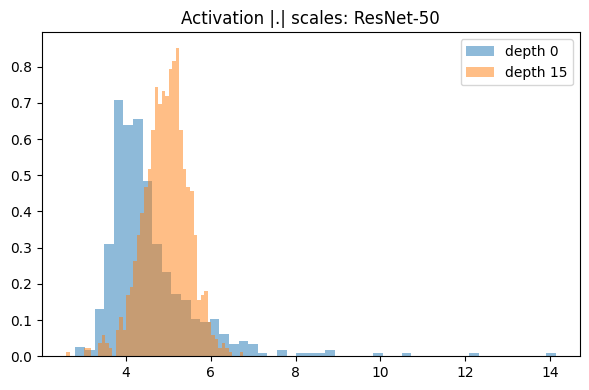

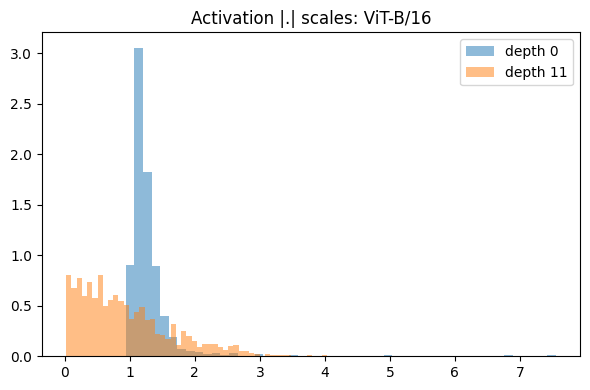

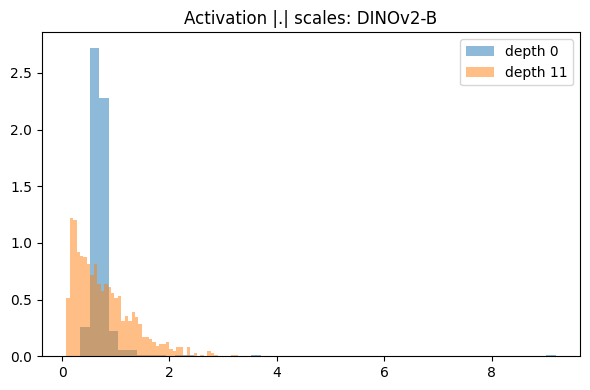

In [6]:

for tag, label in MECH_ARCH_TAGS:
    files = sorted(mech.glob("activation_scale_%s_depth*.npy" % tag))
    if len(files) < 2:
        continue
    a0, a1 = np.load(files[0]), np.load(files[-1])
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.hist(a0, bins=50, alpha=0.5, density=True, label="depth 0")
    ax.hist(a1, bins=50, alpha=0.5, density=True, label="depth %d" % (len(files) - 1))
    ax.set_title("Activation |.| scales: %s" % label)
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / ("activation_scales_%s.png" % tag), dpi=150)
    plt.show()


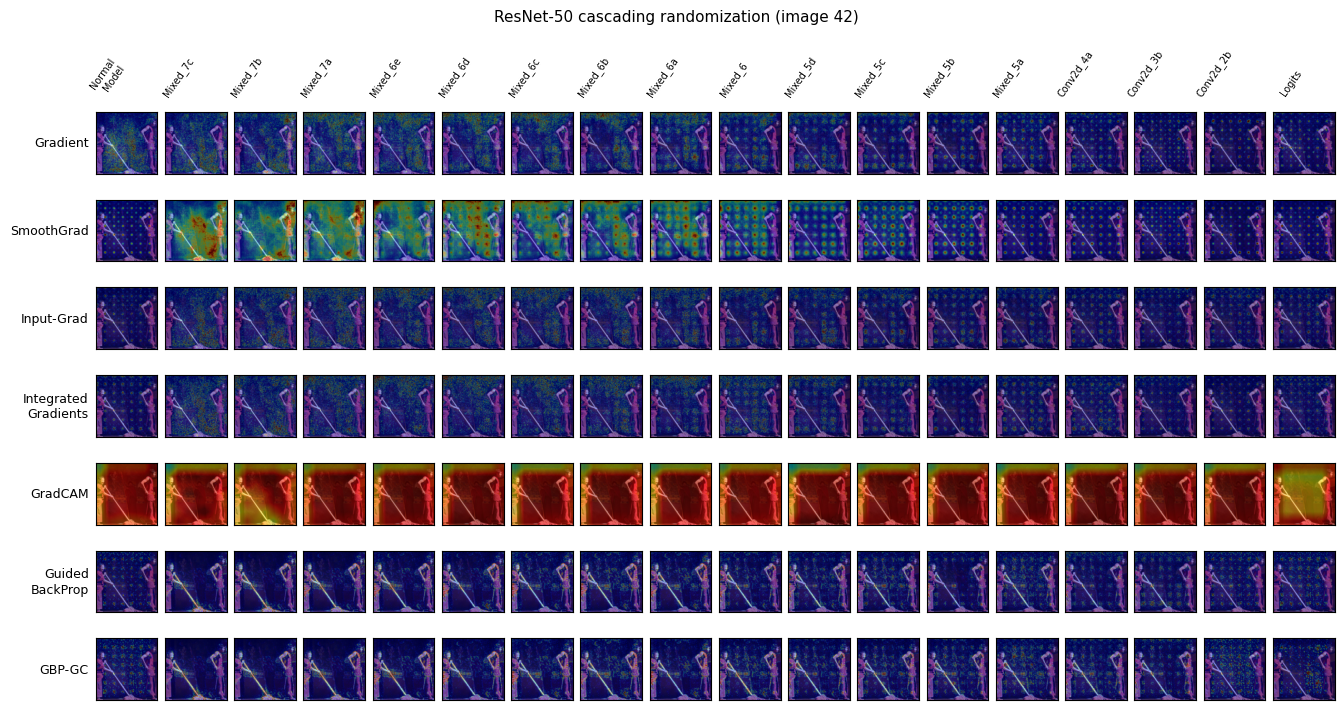

resnet50 -> cascade_grid_resnet50.png (overlay) and cascade_grid_resnet50_masks.png (image 42)


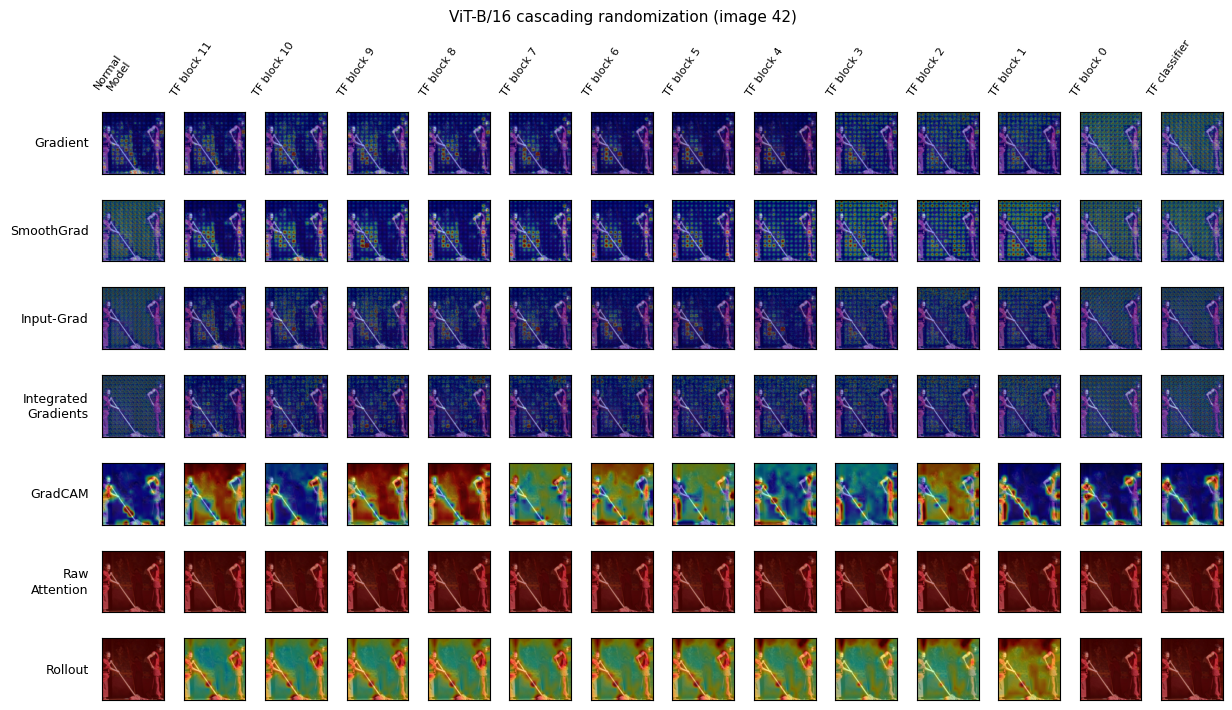

vit -> cascade_grid_vit.png (overlay) and cascade_grid_vit_masks.png (image 42)


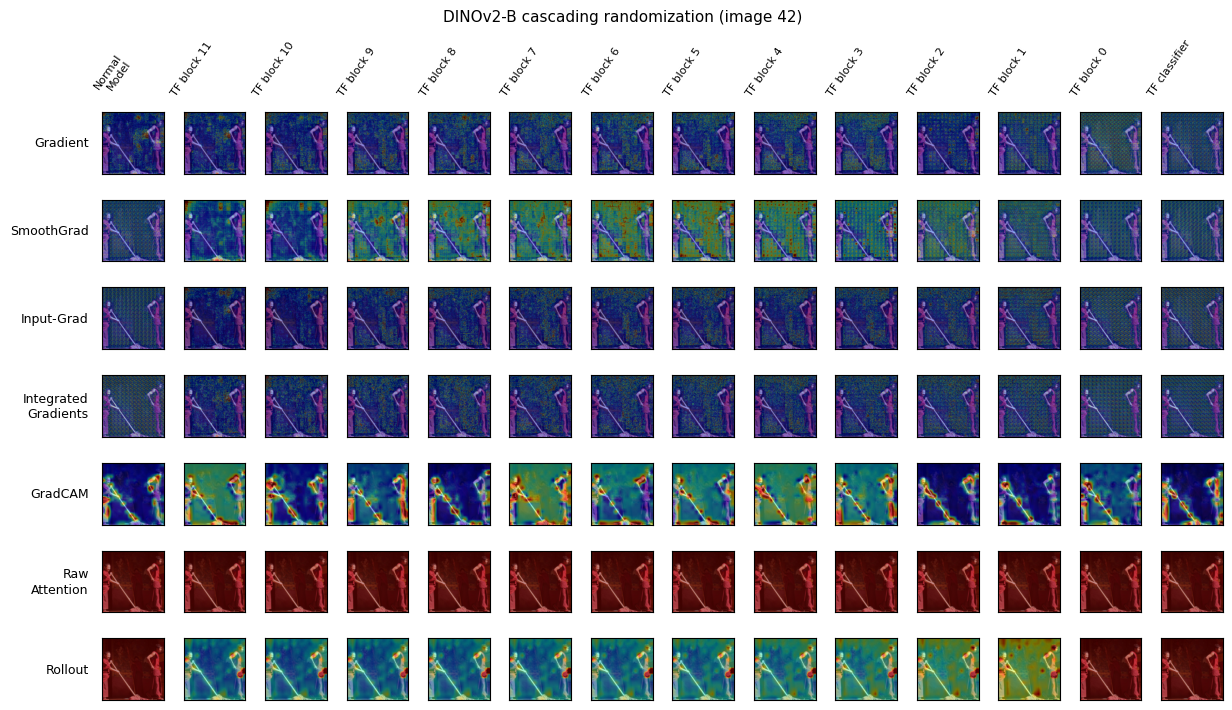

dinov2 -> cascade_grid_dinov2.png (overlay) and cascade_grid_dinov2_masks.png (image 42)
Figures saved to /Users/alexatran/saliency_and_attention/results/figures


In [7]:

import sys
sys.path.insert(0, str(PROJECT_ROOT / "src"))
from viz_utils import plot_cascade_paper_grid, plot_cascading_grid, select_depth_indices

for arch, cfg in ARCHS.items():
    qual_path = RESULTS_ROOT / arch / "qual_bundle.npz"
    if not qual_path.exists():
        print("Skip %s: no qual_bundle.npz (run qual-only Modal job or pipeline with skip_qual=False)" % arch)
        continue
    data = np.load(qual_path, allow_pickle=True)
    img_idx = int(data["image_index"]) if "image_index" in data.files else 0
    order = list(data["order"])
    # None = all cascade steps (Adebayo shows every Mixed_7* / Conv2d_* column)
    depth_indices = select_depth_indices(len(order), max_cols=None)
    plot_cascade_paper_grid(
        qual_path,
        cfg["methods"],
        depth_indices=depth_indices,
        out_path=FIGURES_DIR / ("cascade_grid_%s.png" % arch),
        title=cfg["title"] + " cascading randomization (image %d)" % img_idx,
        arch=arch,
        overlay=True,
        max_depth_cols=None,
        show=True,
    )
    plot_cascade_paper_grid(
        qual_path,
        cfg["methods"],
        depth_indices=depth_indices,
        out_path=FIGURES_DIR / ("cascade_grid_%s_masks.png" % arch),
        title=cfg["title"] + " masks (image %d)" % img_idx,
        arch=arch,
        overlay=False,
        max_depth_cols=None,
        show=False,
    )
    print("%s -> cascade_grid_%s.png (overlay) and cascade_grid_%s_masks.png (image %d)" % (arch, arch, arch, img_idx))

# Optional per-method vertical strips for slides
for arch, method, title in [
    ("resnet50", "gbp", "ResNet-50 GBP"),
    ("resnet50", "input_grad", "ResNet-50 Input-Grad"),
    ("resnet50", "ig", "ResNet-50 IG"),
    ("vit", "ig", "ViT IG"),
    ("vit", "raw_attn", "ViT raw attention"),
    ("dinov2", "ig", "DINOv2 IG"),
]:
    plot_cascading_grid(
        RESULTS_ROOT / arch / "qual_bundle.npz",
        method,
        out_path=FIGURES_DIR / ("cascade_%s_%s.png" % (arch, method)),
        title=title,
        arch=arch,
        overlay=True,
        show=False,
    )

print("Figures saved to", FIGURES_DIR)
